In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Part 1

In [10]:
gt = np.exp(1)-1
print(f'Ground truth: {gt}')

Ground truth: 1.718281828459045


In [11]:
rng = np.random.default_rng(30)

# Estimate
n = 100
U = rng.uniform(size=n)
X = np.exp(U)
estimate = np.mean(X)
print(f"Montecarlo esitmator {estimate}, theoretical: {np.exp(1)-1}")
print(f"Absolute difference: {np.abs(np.exp(1)-1 - estimate)}")


# Confidence interval
s = np.std(X, ddof=1) 
se = s / np.sqrt(n)           
alpha = 0.05
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)

ci_lower = estimate - t_crit * se
ci_upper = estimate + t_crit * se

print(f"95%-Confidence interval: {ci_lower}, {ci_upper}")

Montecarlo esitmator 1.7207379667184908, theoretical: 1.718281828459045
Absolute difference: 0.0024561382594456838
95%-Confidence interval: 1.625743021661111, 1.8157329117758705


# Part 2

In [12]:
rng = np.random.default_rng(30)

# Estimate
n = 100
U = rng.uniform(size=n)
f = lambda x: np.exp(x)
Y = (f(U) + f(1-U)) / 2
estimate = np.mean(Y)
print(f"Antithetic esitmator {estimate}, theoretical: {np.exp(1)-1}")
print(f"Absolute difference: {np.abs(np.exp(1)-1 - estimate)}")

# Confidence interval
s = np.std(Y, ddof=1) 
se = s / np.sqrt(n)           
alpha = 0.05
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)

ci_lower = estimate - t_crit * se
ci_upper = estimate + t_crit * se

print(f"95%-Confidence interval: {ci_lower}, {ci_upper}")

Antithetic esitmator 1.7079341193220712, theoretical: 1.718281828459045
Absolute difference: 0.010347709136973915
95%-Confidence interval: 1.6961008390728838, 1.7197673995712586


# Part 3

In [13]:
rng = np.random.default_rng(30)

# Estimate
n = 100
c = -1.69   # From slides
U = rng.uniform(size=n)
Y = np.exp(U) + c * (U - 0.5)
estimate = np.mean(Y)
print(f"Control variate esitmator {estimate}, theoretical: {np.exp(1)-1}")
print(f"Absolute difference: {np.abs(np.exp(1)-1 - estimate)}")

# Confidence interval
s = np.std(Y, ddof=1) 
se = s / np.sqrt(n)           
alpha = 0.05
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)

ci_lower = estimate - t_crit * se
ci_upper = estimate + t_crit * se

print(f"95%-Confidence interval: {ci_lower}, {ci_upper}")

Control variate esitmator 1.7098575104974887, theoretical: 1.718281828459045
Absolute difference: 0.008424317961556405
95%-Confidence interval: 1.6977001336436615, 1.722014887351316


# Part 4

In [14]:
rng = np.random.default_rng(30)

# Estimate
n = 100
n_strata = 10
nn = int(n/n_strata)
intervals = np.linspace(0,1,num=n_strata+1)
U = []
for i in range(len(intervals)-1):
    i1 = intervals[i]
    i2 = intervals[i+1]
    Ui = rng.uniform(i1,i2,size=nn)
    U.append(Ui)
U = np.array(U)

X = np.exp(U)
estimate = np.mean(X)
print(f"Stratified esitmator {estimate}, theoretical: {np.exp(1)-1}")
print(f"Absolute difference: {np.abs(np.exp(1)-1 - estimate)}")

# Confidence interval
s = np.std(X, ddof=1) 
se = s / np.sqrt(n)           
alpha = 0.05
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)

ci_lower = estimate - t_crit * se
ci_upper = estimate + t_crit * se

print(f"95%-Confidence interval: {ci_lower}, {ci_upper}")

Stratified esitmator 1.7194217484513832, theoretical: 1.718281828459045
Absolute difference: 0.0011399199923380898
95%-Confidence interval: 1.6214430955099894, 1.817400401392777


# Part 5

In [15]:
# Parameters
rng = np.random.default_rng(30)
m = 10
mean_arrivaltime = 1
mean_servicetime = 8

# Run simulation
SIMS = []
ARRIVAL_TIME = []

for k in range(10):

    # Store 
    servers = np.zeros(m)
    t = 0
    blocked_customers = 0

    TIMES = rng.exponential(mean_arrivaltime, size=10_000)
    N = 0

    while N < 10_000:
        # Get time for next arrival
        arrival_time = TIMES[N]
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        # Draw random service time
        service_time = rng.exponential(mean_servicetime)

        # Check if enough servers
        mask = (servers == 0)
        if np.any(mask):
            idx = np.flatnonzero(mask)[0]
            servers[idx] = service_time
        else:
            blocked_customers += 1
        
        N += 1
    

    SIMS.append(blocked_customers/10_000)
    ARRIVAL_TIME.append(np.mean(TIMES))
    

print(SIMS, np.mean(SIMS))

# Sample mean and variance
n = len(SIMS)
sample_mean = np.mean(SIMS)
sample_var = (np.sum(np.array(SIMS)**2)-n*sample_mean**2) * 1/(n - 1)
s_theta = np.sqrt(sample_var)

# Confidence interval
alpha = 0.05
CI_min = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(alpha/2, df=n-1)
CI_max = sample_mean + s_theta/np.sqrt(n)*ss.t.ppf(1-alpha/2, df=n-1)
print(CI_min, CI_max, CI_max-CI_min)

[0.125, 0.1113, 0.1175, 0.1163, 0.1266, 0.1248, 0.114, 0.1155, 0.1243, 0.1241] 0.11994000000000002
0.11595888902952757 0.12392111097047247 0.007962221940944897


## Apply control variates

In [16]:
c = -np.cov(SIMS, ARRIVAL_TIME)[0,1] / np.var(ARRIVAL_TIME)
Y = np.array(SIMS) + c*(np.array(ARRIVAL_TIME) - 1)
estimate = np.mean(Y)
print(f"before: {np.mean(SIMS)}, after {estimate}")
print(f"Theoretical {0.12166106425295149}")
print(f"Absolute difference: {np.mean(SIMS) - estimate}")


# Confidence interval
s = np.std(Y, ddof=1) 
se = s / np.sqrt(n)           
alpha = 0.05
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)

ci_lower = estimate - t_crit * se
ci_upper = estimate + t_crit * se

print(f"95%-Confidence interval: {ci_lower}, {ci_upper}")
print(f"Width {ci_upper-ci_lower}")

before: 0.11994000000000002, after 0.12017392672442506
Theoretical 0.12166106425295149
Absolute difference: -0.00023392672442504314
95%-Confidence interval: 0.11624540606971916, 0.12410244737913097
Width 0.00785704130941181


# Part 7

In [17]:
# Parameters
rng = np.random.default_rng(30)
n = 1_000
a = 0.2

# Sample
Z = rng.normal(size=n)

# Estimate
I = Z > a
estimate = np.mean(I)
print(f"Estimate: {estimate}")
print(f"True value: {1-ss.norm.cdf(a)}")

Estimate: 0.431
True value: 0.420740290560897


### Apply importance sampling

In [18]:
# Parameters
rng = np.random.default_rng(30)
n = 1_00
a = 2
sigma = 1

# Importance sampling
h = lambda x: x > a # This is the indicator function
g = lambda x: ss.norm.pdf(x, loc=a, scale=sigma**2)
f = lambda x: ss.norm.pdf(x, loc=0, scale=1)

Y = rng.normal(loc=a, scale=sigma**2, size=n)
X = h(Y) * f(Y)/g(Y)

estimate = np.mean(X)
print(f"Estimate: {estimate}")
print(f"True value: {1-ss.norm.cdf(a)}")

Estimate: 0.026569427480100744
True value: 0.02275013194817921


In [19]:
A = [0.2,1,2,4]
SIGMA = [0.5,1,2]

for a in A:
    for sigma in SIGMA:
        # Importance sampling
        rng = np.random.default_rng(30)
        n = 1_00
        h = lambda x: x > a # This is the indicator function
        g = lambda x: ss.norm.pdf(x, loc=a, scale=sigma**2)
        f = lambda x: ss.norm.pdf(x, loc=0, scale=1)

        Y = rng.normal(loc=a, scale=sigma**2, size=n)
        X = h(Y) * f(Y)/g(Y)

        estimate = np.mean(X)
        print(f"Parameters: n={n}, a={a}, sigma={sigma}")
        print(f"Estimate: {estimate}")
        print(f"True value: {1-ss.norm.cdf(a)}")
        print("")

Parameters: n=100, a=0.2, sigma=0.5
Estimate: 0.28618943779934364
True value: 0.420740290560897

Parameters: n=100, a=0.2, sigma=1
Estimate: 0.4582835062709147
True value: 0.420740290560897

Parameters: n=100, a=0.2, sigma=2
Estimate: 0.5053865891725537
True value: 0.420740290560897

Parameters: n=100, a=1, sigma=0.5
Estimate: 0.13463315024172814
True value: 0.15865525393145707

Parameters: n=100, a=1, sigma=1
Estimate: 0.17957874996134168
True value: 0.15865525393145707

Parameters: n=100, a=1, sigma=2
Estimate: 0.1695228461321284
True value: 0.15865525393145707

Parameters: n=100, a=2, sigma=0.5
Estimate: 0.022238602650240597
True value: 0.02275013194817921

Parameters: n=100, a=2, sigma=1
Estimate: 0.026569427480100744
True value: 0.02275013194817921

Parameters: n=100, a=2, sigma=2
Estimate: 0.021028517375005395
True value: 0.02275013194817921

Parameters: n=100, a=4, sigma=0.5
Estimate: 3.4312548873746556e-05
True value: 3.167124183311998e-05

Parameters: n=100, a=4, sigma=1
Estim

# Part 8

In [20]:
# Parameters
rng = np.random.default_rng(30)
n = 10_000
LAMBDA = np.linspace(0.1,5,500)

g = lambda x,l: l*np.exp(-l*x)
f = lambda x: (x <= 1)
h = lambda x: np.exp(x)

EST = []
VAR = []

for l in LAMBDA:
    # Sample
    Y = rng.exponential(scale=1/l, size=n)
    X = h(Y) * f(Y)/g(Y,l)

    estimate = np.mean(X)

    #print(f"Lambda: {l:.1f}, Estimate: {estimate}")
    EST.append(estimate)
    VAR.append(np.var(X))

print(f"True: {np.exp(1)-1}")

True: 1.718281828459045


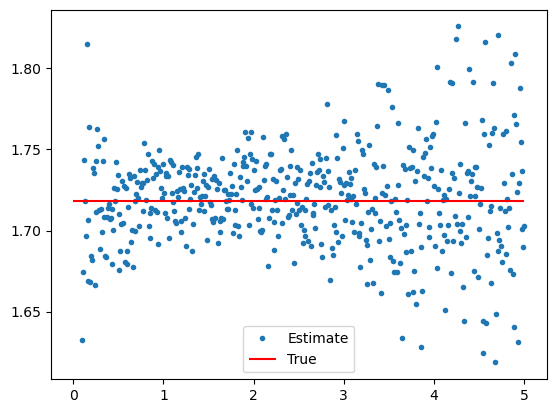

In [21]:
plt.plot(LAMBDA,EST,".", label="Estimate")
plt.hlines(np.exp(1)-1,xmin=0,xmax=5, label="True", color="red")
plt.legend()

Minimum: 3.024201525387358


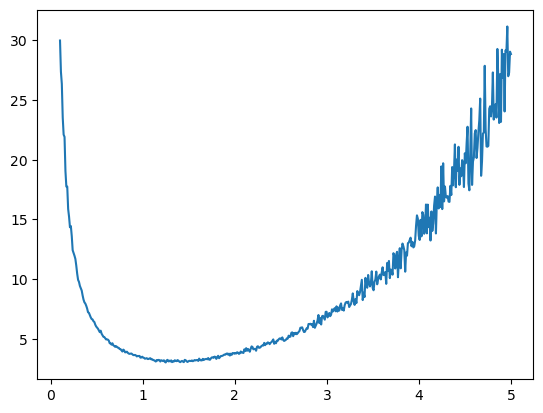

In [22]:
plt.plot(LAMBDA,VAR)
print(f"Minimum: {np.min(VAR)}")

# Part 9

In [23]:
# Parameters
rng = np.random.default_rng(30)
n = 10_000
K = np.linspace(0.1,5,500)
BETA = np.linspace()

g = lambda x,l: l*np.exp(-l*x)
f = lambda x: (x <= 1)
h = lambda x: np.exp(x)

EST = []
VAR = []

for l in LAMBDA:
    # Sample
    Y = rng.pareto()
    X = h(Y) * f(Y)/g(Y,l)

    estimate = np.mean(X)

    #print(f"Lambda: {l:.1f}, Estimate: {estimate}")
    EST.append(estimate)
    VAR.append(np.var(X))

print(f"True: {np.exp(1)-1}")

TypeError: linspace() missing 2 required positional arguments: 'start' and 'stop'